# Bodrum Hotel & Destination Intelligence
## Şikayetvar Final Customer Voice Intelligence

Bu notebook mevcut local scraping çıktılarından üretilen mapping-closure ve clean-v2 katmanını
özetler. Yeni scraping veya model eğitimi yapmaz. Complaint hacmi otel kalitesi değildir;
company reply görünürlüğü çözüm oranı değildir; Google-review denominator metriği gerçek complaint
rate değildir.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'reports').exists(): ROOT = ROOT.parent
R = ROOT / 'reports'; P = ROOT / 'data/processed'
master = pd.read_csv(R / 'sikayetvar_final_customer_voice_master_v3.csv')
closure = pd.read_csv(R / 'sikayetvar_mapping_closure_decisions.csv')
closure_summary = pd.read_csv(R / 'sikayetvar_mapping_closure_summary.csv')
reply = pd.read_csv(R / 'sikayetvar_company_reply_visibility_by_hotel_v3.csv')
aspect = pd.read_csv(R / 'sikayetvar_aspect_summary_v3.csv')
hotel_aspect = pd.read_csv(R / 'sikayetvar_hotel_aspect_summary_v3.csv')
area_aspect = pd.read_csv(R / 'sikayetvar_area_aspect_summary_v3.csv')
readiness = pd.read_csv(R / 'sikayetvar_google_cross_source_readiness_v3.csv')
clean = pd.read_csv(P / 'sikayetvar_complaints_clean_v3.csv', low_memory=False)
print('Loaded:', len(master), 'master hotels |', len(clean), 'clean-v2 complaints')

Loaded: 192 master hotels | 353 clean-v2 complaints


## 1. Data Coverage

In [2]:
coverage = pd.DataFrame({
 'metric':['master_hotels','discovery_covered','verified_pages','complaint_hotels','page_found_no_complaint','not_found','remaining_ambiguous','clean_v3_complaints','company_reply_visible'],
 'value':[len(master), master['mapping_status'].notna().sum(), master['page_status'].isin(['VISIBLE_COMPLAINTS','NO_VISIBLE_COMPLAINT_ON_FOUND_PAGE','VALIDATED_PAGE_COMPLAINTS_NOT_COLLECTED','VALIDATED_PAGE_ONLY_REVIEW_REQUIRED_COMPLAINTS']).sum(), (master['complaint_n']>0).sum(), (master['page_status']=='NO_VISIBLE_COMPLAINT_ON_FOUND_PAGE').sum(), (master['mapping_status']=='NOT_FOUND').sum(), (master['mapping_status']=='AMBIGUOUS_REMAINS').sum(), len(clean), clean['has_company_reply'].fillna(False).astype(bool).sum()]})
display(coverage)

,metric,value
0,master_hotels,192
1,discovery_covered,192
2,verified_pages,62
3,complaint_hotels,44
4,page_found_no_complaint,15
5,not_found,104
6,remaining_ambiguous,9
7,clean_v3_complaints,353
8,company_reply_visible,40


## 2. Mapping Quality — Before vs After

In [3]:
display(closure_summary)
display(closure.groupby(['previous_status','final_status']).size().reset_index(name='hotel_n'))

,metric,value
0,previous_review_required,43
1,previous_ambiguous,1
2,resolved_to_exact,3
3,resolved_to_high_confidence,15
4,rejected_wrong_entity,17
5,remaining_ambiguous,9
6,net_new_matched_hotels,18
7,net_new_matched_complaints,1


,previous_status,final_status,hotel_n
0,AMBIGUOUS,MATCHED_EXACT,1
1,REVIEW_REQUIRED,AMBIGUOUS_REMAINS,9
2,REVIEW_REQUIRED,MATCHED_EXACT,2
3,REVIEW_REQUIRED,MATCHED_HIGH_CONFIDENCE,15
4,REVIEW_REQUIRED,REJECTED_WRONG_ENTITY,17


## 3. Complaint Distribution
Ham complaint count bir kalite sıralaması değildir; yalnız mevcut corpus görünürlüğünü gösterir.

,hotel_name,complaint_n,support_level
6,Kefaluka Resort,29,HIGH_COMPLAINT_SAMPLE
160,MyElla Hotel Resort & Spa,28,HIGH_COMPLAINT_SAMPLE
111,Azure By Yelken Hotel,26,HIGH_COMPLAINT_SAMPLE
114,Yasmin Bodrum Resort,23,HIGH_COMPLAINT_SAMPLE
105,La Blanche Island Bodrum,19,HIGH_COMPLAINT_SAMPLE
65,Royal Asarlik Beach Hotel & Spa,18,HIGH_COMPLAINT_SAMPLE
107,Lujo Hotel Bodrum,15,HIGH_COMPLAINT_SAMPLE
176,Delta Hotels By Marriott Bodrum,14,MODERATE_COMPLAINT_SAMPLE
18,Bitez Garden Life Hotel&Suites,14,MODERATE_COMPLAINT_SAMPLE
129,Petunya Beach Resort,13,MODERATE_COMPLAINT_SAMPLE


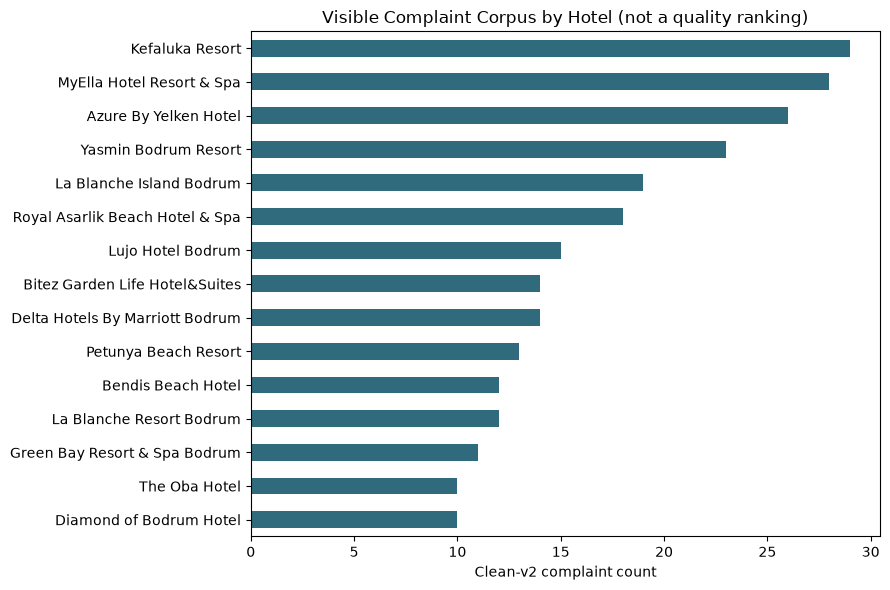

In [4]:
hotel_counts = master.loc[master['complaint_n'].fillna(0).gt(0), ['hotel_name','complaint_n','support_level']].sort_values('complaint_n', ascending=False)
display(hotel_counts.head(20))
ax = hotel_counts.head(15).sort_values('complaint_n').plot.barh(x='hotel_name', y='complaint_n', figsize=(9,6), legend=False, color='#2F6B7C', title='Visible Complaint Corpus by Hotel (not a quality ranking)')
ax.set_xlabel('Clean-v2 complaint count'); ax.set_ylabel(''); plt.tight_layout(); plt.show()

## 4. Area Distribution
Area complaint totals must be read with mapped/validated page coverage.

In [5]:
area_profile = master.groupby('area', dropna=False).agg(project_hotels=('hotel_id','nunique'), validated_pages=('page_status', lambda s:s.isin(['VISIBLE_COMPLAINTS','NO_VISIBLE_COMPLAINT_ON_FOUND_PAGE','VALIDATED_PAGE_COMPLAINTS_NOT_COLLECTED','VALIDATED_PAGE_ONLY_REVIEW_REQUIRED_COMPLAINTS']).sum()), complaint_hotels=('complaint_n',lambda s:s.fillna(0).gt(0).sum()), complaint_n=('complaint_n','sum')).reset_index().sort_values('complaint_n',ascending=False)
display(area_profile)

,area,project_hotels,validated_pages,complaint_hotels,complaint_n
0,Akyarlar,16,8,7,63
7,Güvercinlik,10,8,6,58
8,Kadıkalesi,4,3,3,56
4,Gümbet,15,10,9,44
11,Turgutreis,7,3,3,41
2,Bodrum Merkez,13,6,5,24
1,Bitez,18,5,3,16
9,Ortakent-Yahşi,21,5,3,16
13,Yalıkavak,22,3,1,14
10,Torba,21,5,2,12


## 5. Aspect Intelligence — Existing 18-Aspect Taxonomy

,aspect,complaint_count,mention_rate_pct,unique_hotel_count,unique_area_count,company_response_count,company_response_rate_within_aspect,median_view_count,median_complaint_word_count
0,STAFF_SERVICE,244,69.121813,37,12,30,12.295082,783.0,165.0
1,ROOM,217,61.473088,37,11,26,11.981567,796.0,167.0
2,MANAGEMENT_COMMUNICATION,201,56.940510,38,12,25,12.437811,561.0,162.0
3,FOOD_BEVERAGE,184,52.124646,36,11,22,11.956522,882.5,184.0
4,PAYMENT_REFUND,170,48.158640,37,11,20,11.764706,680.5,158.5
5,CLEANLINESS_HYGIENE,169,47.875354,32,11,15,8.875740,760.0,174.0
6,PRICE_VALUE,161,45.609065,36,12,23,14.285714,583.0,165.0
7,FACILITIES_MAINTENANCE,141,39.943343,32,11,16,11.347518,643.0,176.0
8,RESERVATION,140,39.660057,33,12,20,14.285714,771.5,158.5
9,BEACH_SEA,109,30.878187,29,10,15,13.761468,749.0,175.0


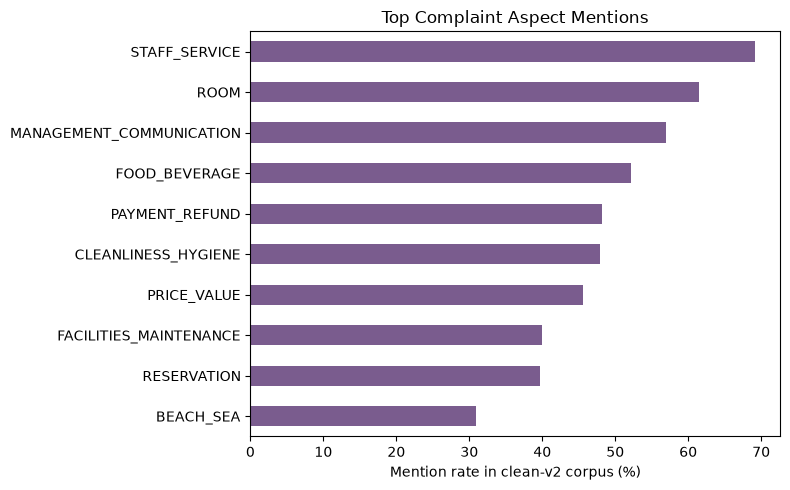

,hotel_id,hotel_name,area,hotel_n,aspect,aspect_count,aspect_mention_rate_pct,small_n_flag
0,BOD002,Armonia Holiday Village & Spa,Akyarlar,8,STAFF_SERVICE,6,75.000000,False
2,BOD002,Armonia Holiday Village & Spa,Akyarlar,8,FOOD_BEVERAGE,6,75.000000,False
3,BOD002,Armonia Holiday Village & Spa,Akyarlar,8,ROOM,6,75.000000,False
20,BOD004,Bendis Beach Hotel,Akyarlar,12,FOOD_BEVERAGE,9,75.000000,False
21,BOD004,Bendis Beach Hotel,Akyarlar,12,ROOM,9,75.000000,False
18,BOD004,Bendis Beach Hotel,Akyarlar,12,STAFF_SERVICE,8,66.666667,False
36,BOD006,Club Marma Hotel,Akyarlar,5,STAFF_SERVICE,5,100.000000,False
38,BOD006,Club Marma Hotel,Akyarlar,5,FOOD_BEVERAGE,4,80.000000,False
37,BOD006,Club Marma Hotel,Akyarlar,5,CLEANLINESS_HYGIENE,2,40.000000,False
54,BOD007,Kefaluka Resort,Akyarlar,29,STAFF_SERVICE,19,65.517241,False


,area,area_n,aspect,aspect_count,aspect_mention_rate_pct,small_n_flag
0,Akyarlar,63,STAFF_SERVICE,46,73.015873,False
3,Akyarlar,63,ROOM,41,65.079365,False
2,Akyarlar,63,FOOD_BEVERAGE,38,60.317460,False
21,Bitez,16,ROOM,14,87.500000,False
19,Bitez,16,CLEANLINESS_HYGIENE,13,81.250000,False
18,Bitez,16,STAFF_SERVICE,12,75.000000,False
36,Bodrum Merkez,24,STAFF_SERVICE,19,79.166667,False
39,Bodrum Merkez,24,ROOM,17,70.833333,False
37,Bodrum Merkez,24,CLEANLINESS_HYGIENE,15,62.500000,False
87,Gümbet,44,MANAGEMENT_COMMUNICATION,29,65.909091,False


In [6]:
display(aspect.head(10))
ax = aspect.head(10).sort_values('mention_rate_pct').plot.barh(x='aspect', y='mention_rate_pct', figsize=(8,5), legend=False, color='#7A5C8E', title='Top Complaint Aspect Mentions')
ax.set_xlabel('Mention rate in clean-v2 corpus (%)'); ax.set_ylabel(''); plt.tight_layout(); plt.show()
display(hotel_aspect.loc[(~hotel_aspect['small_n_flag']) & hotel_aspect['aspect_count'].gt(0)].sort_values(['hotel_id','aspect_mention_rate_pct'],ascending=[True,False]).groupby('hotel_id').head(3).head(30))
display(area_aspect.loc[(~area_aspect['small_n_flag']) & area_aspect['aspect_count'].gt(0)].sort_values(['area','aspect_mention_rate_pct'],ascending=[True,False]).groupby('area').head(3))

## 6. Company Response Visibility
Görünür cevap, problemin çözüldüğü veya hizmetin iyi olduğu anlamına gelmez.

In [7]:
display(reply.sort_values(['complaint_n','company_reply_visibility_pct'], ascending=[False,False]))

,hotel_id,hotel_name,area,complaint_n,company_reply_n,reply_text_nonempty_n,reply_date_available_n,parser_artifact_n,duplicate_reply_n,company_reply_visibility_pct,interpretation
3,BOD007,Kefaluka Resort,Akyarlar,29,22,22,22,1,0,75.862069,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION
42,BOD161,MyElla Hotel Resort & Spa,Turgutreis,28,0,0,0,0,0,0.000000,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION
32,BOD112,Azure By Yelken Hotel,Kadıkalesi,26,1,1,1,0,0,3.846154,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION
34,BOD115,Yasmin Bodrum Resort,Kadıkalesi,23,0,0,0,0,0,0.000000,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION
28,BOD106,La Blanche Island Bodrum,Güvercinlik,19,5,5,5,0,0,26.315789,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION
20,BOD066,Royal Asarlik Beach Hotel & Spa,Gümbet,18,0,0,0,0,0,0.000000,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION
30,BOD108,Lujo Hotel Bodrum,Güvercinlik,15,0,0,0,0,0,0.000000,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION
7,BOD019,Bitez Garden Life Hotel&Suites,Bitez,14,0,0,0,0,0,0.000000,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION
43,BOD177,Delta Hotels By Marriott Bodrum,Yalıkavak,14,0,0,0,0,0,0.000000,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION
37,BOD130,Petunya Beach Resort,Ortakent-Yahşi,13,0,0,0,0,0,0.000000,COMPANY_RESPONSE_VISIBILITY_NOT_RESOLUTION


## 7. Cross-Platform Complaint Visibility Indicator
Yalnız pozitif Google-review denominator ile hesaplanır; gerçek complaint rate değildir.

In [8]:
visibility = master.loc[master['complaint_visibility_per_1000_google_reviews'].notna(), ['hotel_name','complaint_n','google_review_count','complaint_visibility_per_1000_google_reviews','visibility_support_flag','data_quality_note']].sort_values('complaint_visibility_per_1000_google_reviews',ascending=False)
display(visibility)

,hotel_name,complaint_n,google_review_count,complaint_visibility_per_1000_google_reviews,visibility_support_flag,data_quality_note
111,Azure By Yelken Hotel,26,565,46.017699,LOW_DENOMINATOR,missing_text_n=0; raw_count_not_quality; reply...
76,Ladonia Hotels Zemda,7,376,18.617021,LOW_DENOMINATOR,missing_text_n=0; raw_count_not_quality; reply...
152,The Oba Hotel,10,603,16.583748,LOW_DENOMINATOR,missing_text_n=0; raw_count_not_quality; reply...
160,MyElla Hotel Resort & Spa,28,2926,9.569378,STRONGER_DENOMINATOR,missing_text_n=0; raw_count_not_quality; reply...
119,Celeste Bella Luxury Hotel & Spa,2,258,7.751938,LOW_DENOMINATOR,missing_text_n=0; raw_count_not_quality; reply...
6,Kefaluka Resort,29,4293,6.755183,STRONGER_DENOMINATOR,missing_text_n=2; raw_count_not_quality; reply...
176,Delta Hotels By Marriott Bodrum,14,2444,5.728314,STRONGER_DENOMINATOR,missing_text_n=0; raw_count_not_quality; reply...
18,Bitez Garden Life Hotel&Suites,14,2527,5.540166,STRONGER_DENOMINATOR,missing_text_n=0; raw_count_not_quality; reply...
65,Royal Asarlik Beach Hotel & Spa,18,3511,5.126745,STRONGER_DENOMINATOR,missing_text_n=0; raw_count_not_quality; reply...
3,Bendis Beach Hotel,12,2469,4.860267,STRONGER_DENOMINATOR,missing_text_n=0; raw_count_not_quality; reply...


## 8. Hotel Customer Voice Profiles

In [9]:
display(master.loc[master['complaint_n'].fillna(0).gt(0), ['hotel_id','hotel_name','area','complaint_n','top_aspects','company_reply_visibility_pct','complaint_visibility_per_1000_google_reviews','support_level','data_quality_note']].sort_values('complaint_n',ascending=False))

,hotel_id,hotel_name,area,complaint_n,top_aspects,company_reply_visibility_pct,complaint_visibility_per_1000_google_reviews,support_level,data_quality_note
6,BOD007,Kefaluka Resort,Akyarlar,29,STAFF_SERVICE:65.5%|MANAGEMENT_COMMUNICATION:6...,75.862069,6.755183,HIGH_COMPLAINT_SAMPLE,missing_text_n=2; raw_count_not_quality; reply...
160,BOD161,MyElla Hotel Resort & Spa,Turgutreis,28,STAFF_SERVICE:78.6%|CLEANLINESS_HYGIENE:64.3%|...,0.000000,9.569378,HIGH_COMPLAINT_SAMPLE,missing_text_n=0; raw_count_not_quality; reply...
111,BOD112,Azure By Yelken Hotel,Kadıkalesi,26,STAFF_SERVICE:76.9%|PAYMENT_REFUND:73.1%|ROOM:...,3.846154,46.017699,HIGH_COMPLAINT_SAMPLE,missing_text_n=0; raw_count_not_quality; reply...
114,BOD115,Yasmin Bodrum Resort,Kadıkalesi,23,STAFF_SERVICE:65.2%|MANAGEMENT_COMMUNICATION:5...,0.000000,4.115226,HIGH_COMPLAINT_SAMPLE,missing_text_n=2; raw_count_not_quality; reply...
105,BOD106,La Blanche Island Bodrum,Güvercinlik,19,STAFF_SERVICE:73.7%|ROOM:68.4%|BEACH_SEA:47.4%,26.315789,2.881407,HIGH_COMPLAINT_SAMPLE,missing_text_n=1; raw_count_not_quality; reply...
65,BOD066,Royal Asarlik Beach Hotel & Spa,Gümbet,18,RESERVATION:66.7%|STAFF_SERVICE:61.1%|MANAGEME...,0.000000,5.126745,HIGH_COMPLAINT_SAMPLE,missing_text_n=0; raw_count_not_quality; reply...
107,BOD108,Lujo Hotel Bodrum,Güvercinlik,15,STAFF_SERVICE:66.7%|PRICE_VALUE:46.7%|FAMILY_C...,0.000000,4.703669,HIGH_COMPLAINT_SAMPLE,missing_text_n=0; raw_count_not_quality; reply...
176,BOD177,Delta Hotels By Marriott Bodrum,Yalıkavak,14,ROOM:92.9%|STAFF_SERVICE:85.7%|CLEANLINESS_HYG...,0.000000,5.728314,MODERATE_COMPLAINT_SAMPLE,missing_text_n=0; raw_count_not_quality; reply...
18,BOD019,Bitez Garden Life Hotel&Suites,Bitez,14,CLEANLINESS_HYGIENE:85.7%|ROOM:85.7%|STAFF_SER...,0.000000,5.540166,MODERATE_COMPLAINT_SAMPLE,missing_text_n=0; raw_count_not_quality; reply...
129,BOD130,Petunya Beach Resort,Ortakent-Yahşi,13,MANAGEMENT_COMMUNICATION:84.6%|PAYMENT_REFUND:...,0.000000,4.838109,MODERATE_COMPLAINT_SAMPLE,missing_text_n=0; raw_count_not_quality; reply...


## 9. Google Travel Cross-Source Readiness

In [10]:
display(readiness)

,check,status,value,evidence_or_note
0,COMMON_HOTEL_ID_KEY,PASS,hotel_id,Both corpora expose hotel_id as the intended j...
1,GOOGLE_TRAVEL_CLEAN_DATASET,PASS,2336,C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelr...
2,GOOGLE_TRAVEL_HOTEL_COVERAGE,PASS,104,Unique Google Travel hotel_id count.
3,SIKAYETVAR_CLEAN_V2,PASS,353,data/processed/sikayetvar_complaints_clean_v3.csv
4,HOTEL_COVERAGE_INTERSECTION,PASS,27,Complaint-bearing Sikayetvar hotels also prese...
5,ASPECT_TAXONOMY_ALIGNMENT,PARTIAL,18,Sikayetvar taxonomy is explicit; Google Travel...
6,SOURCE_SEMANTIC_ASYMMETRY,CAUTION,GENERAL_REVIEWS_VS_COMPLAINT_CORPUS,Compare general customer voice versus complain...
7,RATING_COMPLAINT_ASYMMETRY,CAUTION,DIFFERENT_SELECTION_PROCESSES,Ratings and complaint presence have different ...


## 10. Limitations

- Şikayetvar complaint-focused ve self-selected bir corpustur.
- `NOT_FOUND`, sıfır complaint değildir; doğrulanmış sayfa bulunamadığını gösterir.
- `PAGE_FOUND_NO_COMPLAINT`, yalnız bulunan sayfada görünür complaint olmadığını gösterir.
- Mapping closure sonrası doğrulanan fakat daha önce scrape edilmemiş sayfalar için complaint corpusu eksiktir.
- Aspect detection mevcut rule-based 18-aspect taxonomy’yi korur; sentiment veya topic modeli değildir.
- Google Travel genel review corpusu ile Şikayetvar aynı sentiment distribution gibi kıyaslanmamalıdır.

In [11]:
assert master['hotel_id'].is_unique and len(master)==192
assert clean['canonical_complaint_url'].is_unique
assert set(closure['final_status']).issubset({'MATCHED_EXACT','MATCHED_HIGH_CONFIDENCE','REJECTED_WRONG_ENTITY','AMBIGUOUS_REMAINS'})
assert (master.loc[master['mapping_status']=='NOT_FOUND','page_status']=='NO_VALIDATED_SIKAYETVAR_PAGE').all()
assert (master.loc[master['mapping_status']=='PAGE_FOUND_NO_COMPLAINT','page_status']=='NO_VISIBLE_COMPLAINT_ON_FOUND_PAGE').all()
print('FINAL NOTEBOOK VALIDATION: PASS')

FINAL NOTEBOOK VALIDATION: PASS
